In [21]:
from pathlib import Path
import lsstypes as types
import matplotlib.pyplot as plt

In [22]:
dirname = Path('/pscratch/sd/a/adematti/measurements/angular_shotnoise')

spectra = {}
for weight in ['WEIGHT_SYS', 'WEIGHT_IMLIN', 'WEIGHT_IMLIN_DES']:
    spectra[weight] = types.read(dirname / f'mesh2_spectrum_ELG_LOPnotqso_SGC_{weight}.h5').select(k=slice(0, None, 5))

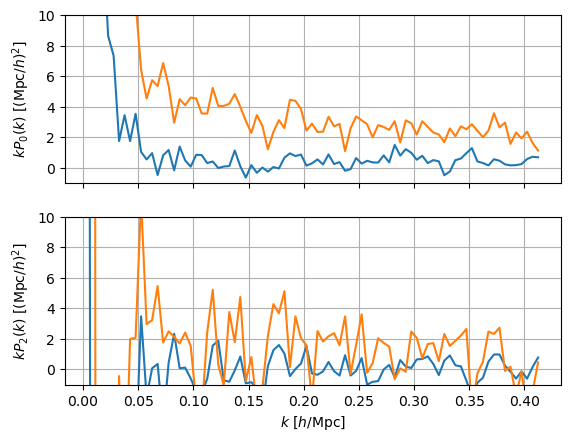

In [26]:
ells = spectra['WEIGHT_SYS'].ells[:2]
fig, lax = plt.subplots(len(ells), sharex=True)
lax = lax.ravel()
for ill, ell in enumerate(ells):
    ax = lax[ill]
    ax.plot(k:=spectra['WEIGHT_SYS'].get(ell).coords('k'), k * (spectra['WEIGHT_IMLIN'].get(ell).value() - spectra['WEIGHT_SYS'].get(ell).value()), color='C0')
    ax.plot(k:=spectra['WEIGHT_SYS'].get(ell).coords('k'), k * (spectra['WEIGHT_IMLIN_DES'].get(ell).value() - spectra['WEIGHT_SYS'].get(ell).value()), color='C1')
    ax.set_ylabel(rf'$k P_{ell:d}(k)$ [$(\mathrm{{Mpc}}/h)^2$]')
    ax.set_ylim(-1., 10.)
    ax.grid(True)
ax.set_xlabel(r'$k$ [$h/\mathrm{Mpc}$]')
plt.show()